In [1]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ANÁLISIS DESCRIPTIVO
# Proyecto: Calidad del agua en ríos de Sudáfrica
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

In [2]:
# +++++++++++++++++++++++++++++++++
#  IMPORTACIÓN DE LIBRERÍAS
# +++++++++++++++++++++++++++++++++
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# +++++++++++++++++++++++++++++++++
#  CARGA DEL DATASET
# +++++++++++++++++++++++++++++++++
df_sucio = pd.read_csv("WATER_TERRACLIMATE_LANDSAT.csv")

In [4]:
# +++++++++++++++++++++++++++++++++
#  VISTA PRELIMINAR para ver hay columnas repetidas
# +++++++++++++++++++++++++++++++++
print("Pimeras filas del dataset:\n",df_sucio.head())

print("\nNombre de las columnas:",df_sucio.columns)

print("\nInformacion sobre las variables:",df_sucio.info())

Pimeras filas del dataset:
     Latitude  Longitude Sample Date  Total Alkalinity  Electrical Conductance  \
0 -28.760833  17.730278  02-01-2011           128.912                   555.0   
1 -26.861111  28.884722  03-01-2011            74.720                   162.9   
2 -26.450000  28.085833  03-01-2011            89.254                   573.0   
3 -27.671111  27.236944  03-01-2011            82.000                   203.6   
4 -27.356667  27.286389  03-01-2011            56.100                   145.1   

   Dissolved Reactive Phosphorus  Latitude0  Longitude0 Sample Date0    pet  \
0                           10.0 -28.760833   17.730278   02-01-2011  174.2   
1                          163.0 -26.861111   28.884722   03-01-2011  124.1   
2                           80.0 -26.450000   28.085833   03-01-2011  127.5   
3                          101.0 -27.671111   27.236944   03-01-2011  129.7   
4                          151.0 -27.356667   27.286389   03-01-2011  129.2   

   Latitud

In [5]:
#Comprobar si las columnas son iguales 
(df_sucio["Latitude"]==df_sucio["Latitude0"]).sum()

np.int64(9319)

In [6]:
# +++++++++++++++++++++++++++++++++
#  ElIMINAR COLUMNAS REPETIDAS
# +++++++++++++++++++++++++++++++++
df_limpio = df_sucio.drop(columns=[
    "Latitude0",
    "Longitude0",
    "Sample Date0",
    "Latitude1",
    "Longitude1",
    "Sample Date1"
])

#Comprobación de las columnas en el nuevo dataframe
df_limpio.columns

Index(['Latitude', 'Longitude', 'Sample Date', 'Total Alkalinity',
       'Electrical Conductance', 'Dissolved Reactive Phosphorus', 'pet', 'nir',
       'green', 'swir16', 'swir22', 'NDMI', 'MNDWI'],
      dtype='str')

In [7]:
# +++++++++++++++++++++++++++++++++
# CONVERSIÓN DE VARIABLES
# +++++++++++++++++++++++++++++++++
# Convertir la columna de fecha a formato datetime
df_limpio["Sample Date"] = pd.to_datetime(df_limpio["Sample Date"],dayfirst=True)

# +++++++++++++++++++++++++++++++++
#  VERIFICACIÓN DE TIPOS DE DATOS
# +++++++++++++++++++++++++++++++++
print("Tipos de datos actualizaso:\n",df_limpio.dtypes)

Tipos de datos actualizaso:
 Latitude                                float64
Longitude                               float64
Sample Date                      datetime64[us]
Total Alkalinity                        float64
Electrical Conductance                  float64
Dissolved Reactive Phosphorus           float64
pet                                     float64
nir                                     float64
green                                   float64
swir16                                  float64
swir22                                  float64
NDMI                                    float64
MNDWI                                   float64
dtype: object


In [8]:
# +++++++++++++++++++++++++++++++++
#  CREACION NUEVO ARCHIVO 
# +++++++++++++++++++++++++++++++++
df_limpio.to_csv("WATER_TERRACLIMATE_LANDSAT_limpio.csv", index=False)


In [9]:
# +++++++++++++++++++++++++++++++++
#  CARGA DEL DATASET NUEVO
# +++++++++++++++++++++++++++++++++
df = pd.DataFrame(pd.read_csv(r"WATER_TERRACLIMATE_LANDSAT_limpio.csv"))

In [10]:
# +++++++++++++++++++++++++++++++++
#  VISTA PRELIMINAR
# +++++++++++++++++++++++++++++++++
print("Pimeras filas del dataset:\n",df.head())

print("\nDimensiones del dataset:",df.shape)

print("\nNombre de las columnas:",df.columns)

print("\nInformacion sobre las variables:",df.info())

Pimeras filas del dataset:
     Latitude  Longitude Sample Date  Total Alkalinity  Electrical Conductance  \
0 -28.760833  17.730278  2011-01-02           128.912                   555.0   
1 -26.861111  28.884722  2011-01-03            74.720                   162.9   
2 -26.450000  28.085833  2011-01-03            89.254                   573.0   
3 -27.671111  27.236944  2011-01-03            82.000                   203.6   
4 -27.356667  27.286389  2011-01-03            56.100                   145.1   

   Dissolved Reactive Phosphorus    pet      nir    green   swir16   swir22  \
0                           10.0  174.2  11190.0  11426.0   7687.5   7645.0   
1                          163.0  124.1  17658.5   9550.0  13746.5  10574.0   
2                           80.0  127.5  15210.0  10720.0  17974.0  14201.0   
3                          101.0  129.7  14887.0  10943.0  13522.0  11403.0   
4                          151.0  129.2  16828.5   9502.5  12665.5   9643.0   

       NDM

In [11]:
# +++++++++++++++++++++++++++++++++
#  VALORES NULOS
# +++++++++++++++++++++++++++++++++
print("Valores nulos por columna:\n",df.isna().sum())

Valores nulos por columna:
 Latitude                            0
Longitude                           0
Sample Date                         0
Total Alkalinity                    0
Electrical Conductance              0
Dissolved Reactive Phosphorus       0
pet                                 0
nir                              1085
green                            1085
swir16                           1085
swir22                           1085
NDMI                             1085
MNDWI                            1085
dtype: int64


In [12]:
# +++++++++++++++++++++++++++++++++
#  VALORES DUPLICADOS
# +++++++++++++++++++++++++++++++++
print("Cantidad de registros duplicados:",df.duplicated().sum())

Cantidad de registros duplicados: 0


In [13]:
# +++++++++++++++++++++++++++++++++
#  ESTADÍSTICAS DESCRIPTIVAS
# +++++++++++++++++++++++++++++++++
print("Estadistica descriptiva:\n",df.describe())

Estadistica descriptiva:
           Latitude    Longitude  Total Alkalinity  Electrical Conductance  \
count  9319.000000  9319.000000       9319.000000             9319.000000   
mean    -28.474988    26.868414        119.108208              485.004146   
std       2.760282     3.535164         74.692591              341.937736   
min     -34.405833    17.730278          4.800000               15.120000   
25%     -30.160091    26.126667         55.811000              207.050000   
50%     -28.058889    27.409060        113.300000              402.000000   
75%     -26.861111    29.245556        170.230000              693.000000   
max     -22.225556    32.325000        361.676000             1506.000000   

       Dissolved Reactive Phosphorus          pet           nir         green  \
count                    9319.000000  9319.000000   8234.000000   8234.000000   
mean                       43.525338   175.166082  14045.485426   9983.213141   
std                        50.980194 

In [14]:
# +++++++++++++++++++++++++++++++++
#  MEDIA, MEDIANA Y MODA
# +++++++++++++++++++++++++++++++++

# Seleccionar únicamente variables numéricas
variables_numericas = df.select_dtypes(include=[np.number])

# Media
media = variables_numericas.mean()

# Mediana
mediana = variables_numericas.median()

# Moda
moda = variables_numericas.mode().iloc[0]

# Crear tabla resumen
resumen_medidas = pd.DataFrame({
    "Media": media,
    "Mediana": mediana,
    "Moda": moda
})

print(resumen_medidas)

                                      Media       Mediana          Moda
Latitude                         -28.474988    -28.058889    -29.161667
Longitude                         26.868414     27.409060     26.632278
Total Alkalinity                 119.108208    113.300000     10.000000
Electrical Conductance           485.004146    402.000000    960.000000
Dissolved Reactive Phosphorus     43.525338     20.000000     10.000000
pet                              175.166082    172.500000    191.900010
nir                            14045.485426  14183.000000  15515.500000
green                           9983.213141   9801.000000  10247.000000
swir16                         13567.459315  13704.250000  12823.000000
swir22                         11425.538377  11265.250000  10403.500000
NDMI                               0.021374      0.021549      0.095012
MNDWI                             -0.144268     -0.167901     -0.111660


In [15]:
# +++++++++++++++++++++++++++++++++
#  DETECCIÓN DE OUTLIERS (IQR)
# +++++++++++++++++++++++++++++++++

# Seleccionar variables numéricas
variables_numericas = df.select_dtypes(include=[np.number])

# Crear diccionario para guardar resultados
outliers_info = {}

# Calcular outliers por variable
for columna in variables_numericas.columns:

    Q1 = variables_numericas[columna].quantile(0.25)
    Q3 = variables_numericas[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = variables_numericas[
        (variables_numericas[columna] < limite_inferior) |
        (variables_numericas[columna] > limite_superior)
    ]

    outliers_info[columna] = len(outliers)

# Mostrar resultados
outliers_df = pd.DataFrame.from_dict(
    outliers_info,
    orient='index',
    columns=['Cantidad de Outliers']
)

print(outliers_df)

                               Cantidad de Outliers
Latitude                                          0
Longitude                                      1131
Total Alkalinity                                 43
Electrical Conductance                          169
Dissolved Reactive Phosphorus                  1398
pet                                             194
nir                                             474
green                                           412
swir16                                          172
swir22                                          209
NDMI                                             41
MNDWI                                           456


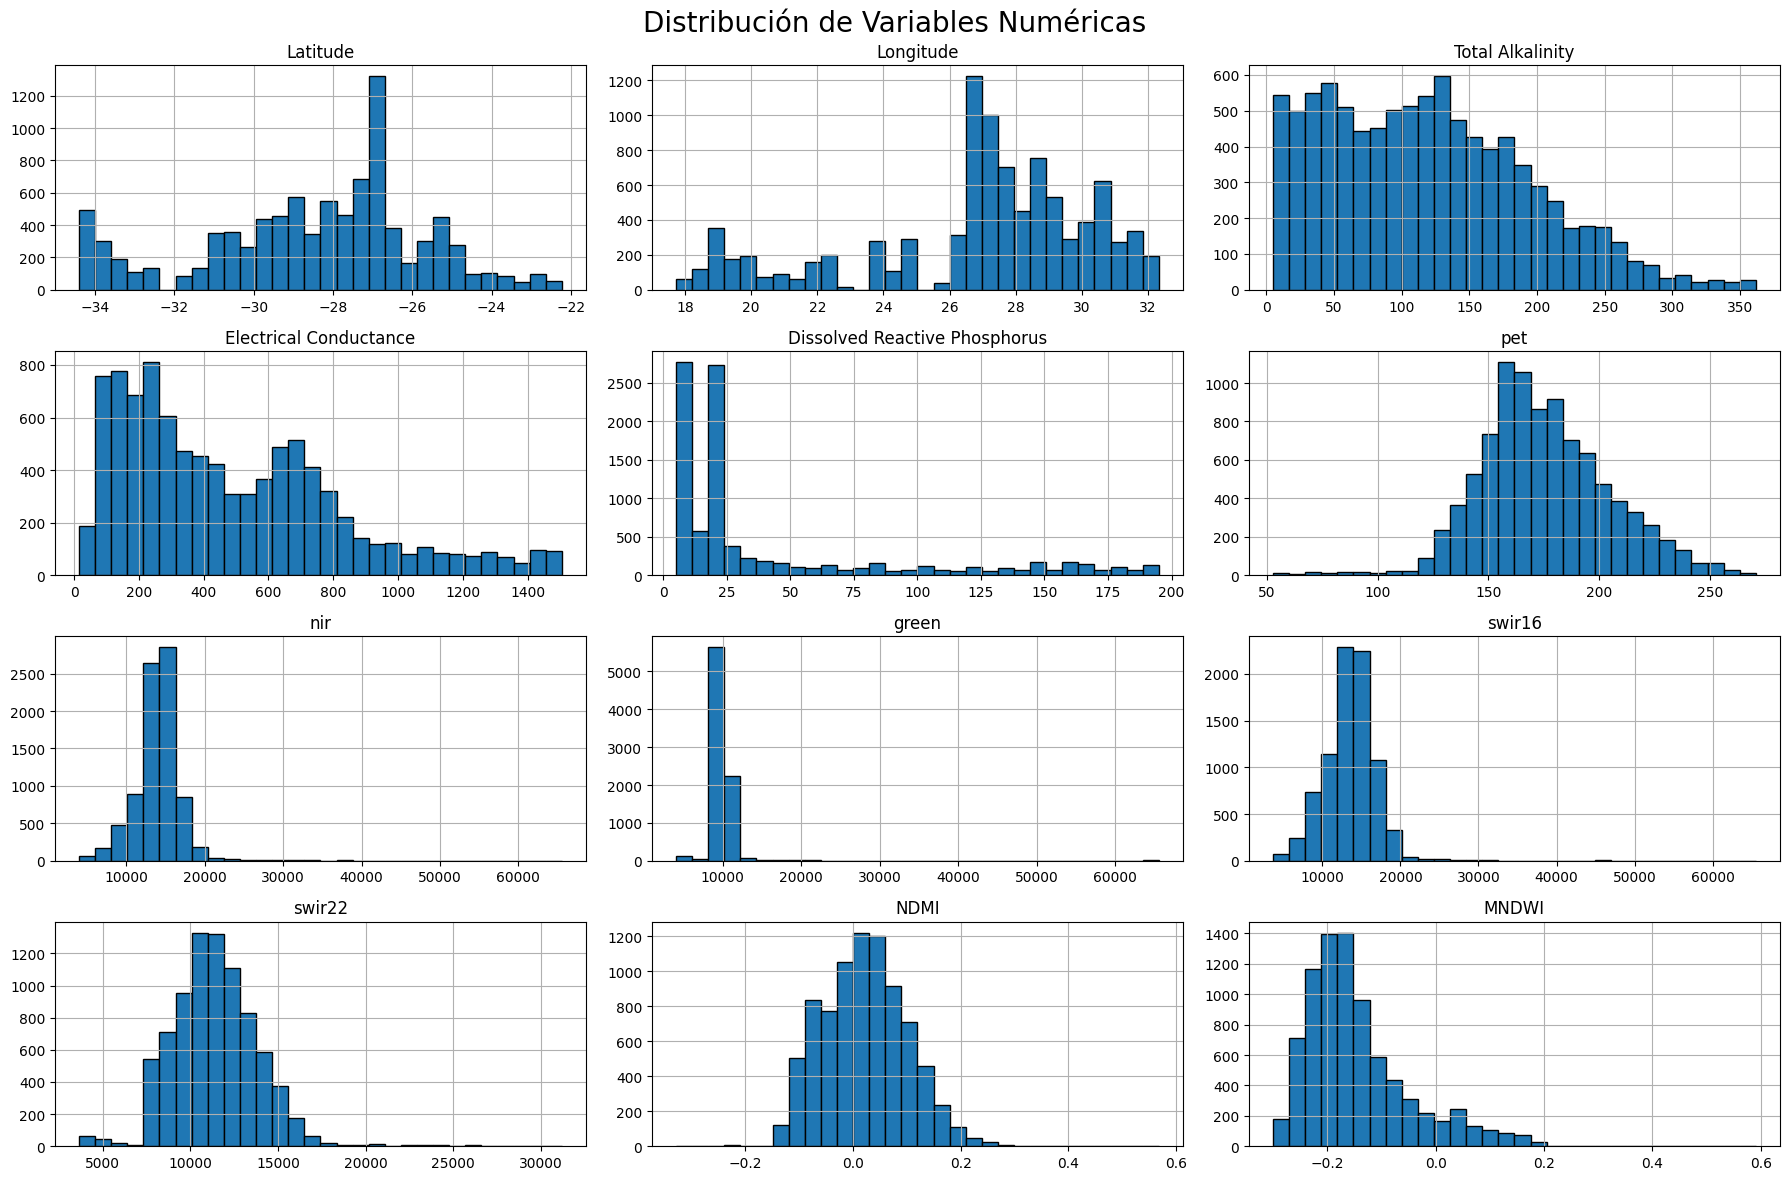

In [16]:
# +++++++++++++++++++++++++++++++++
# EDA - HISTOGRAMAS
# +++++++++++++++++++++++++++++++++

# Seleccionar variables numéricas
variables_numericas = df.select_dtypes(include=[np.number])

# Crear histogramas
variables_numericas.hist(
    figsize=(18, 12),
    bins=30,
    edgecolor='black'
)

# Ajustar diseño
plt.suptitle("Distribución de Variables Numéricas", fontsize=20)
plt.tight_layout()

# Mostrar gráficas
plt.show()

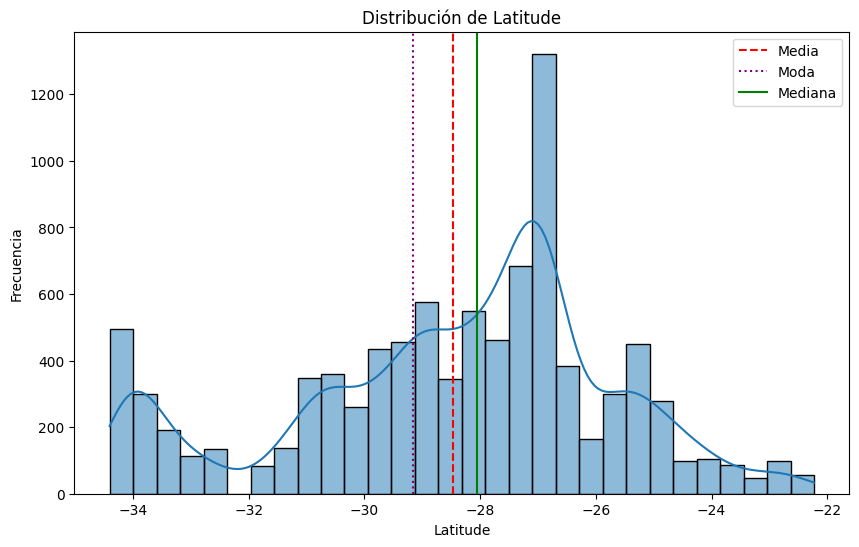

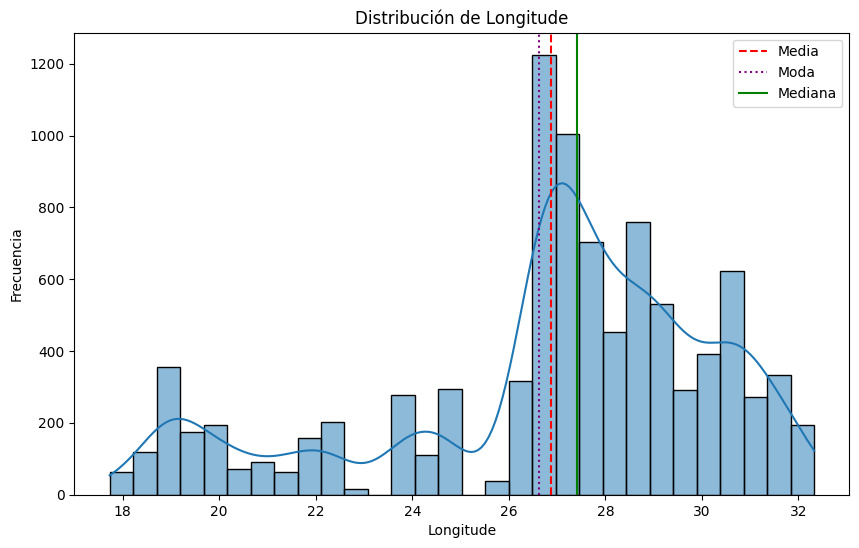

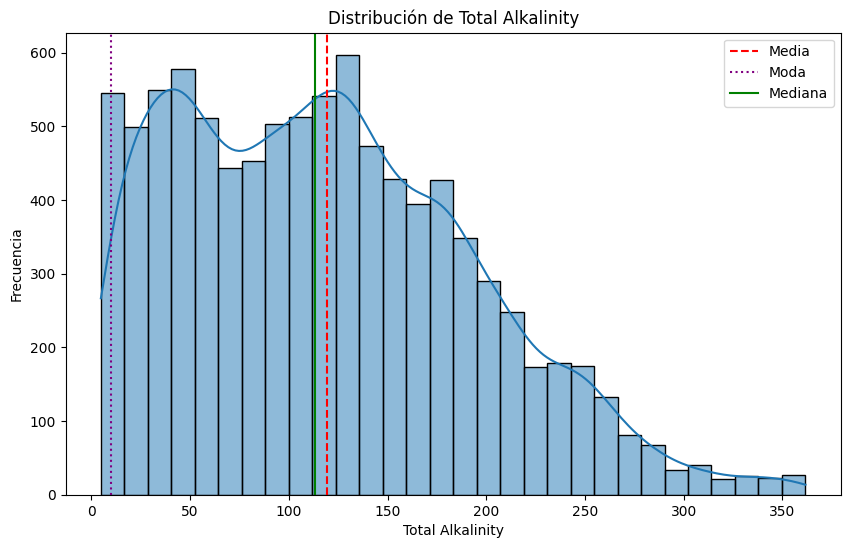

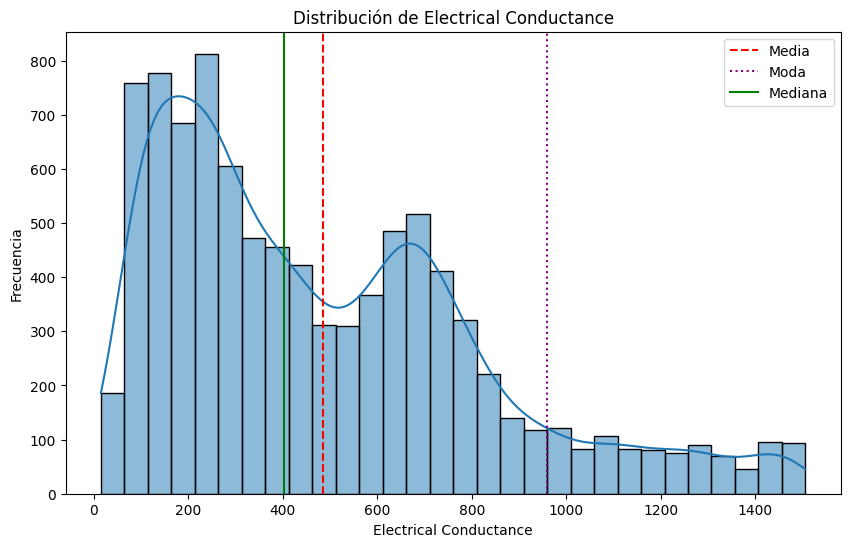

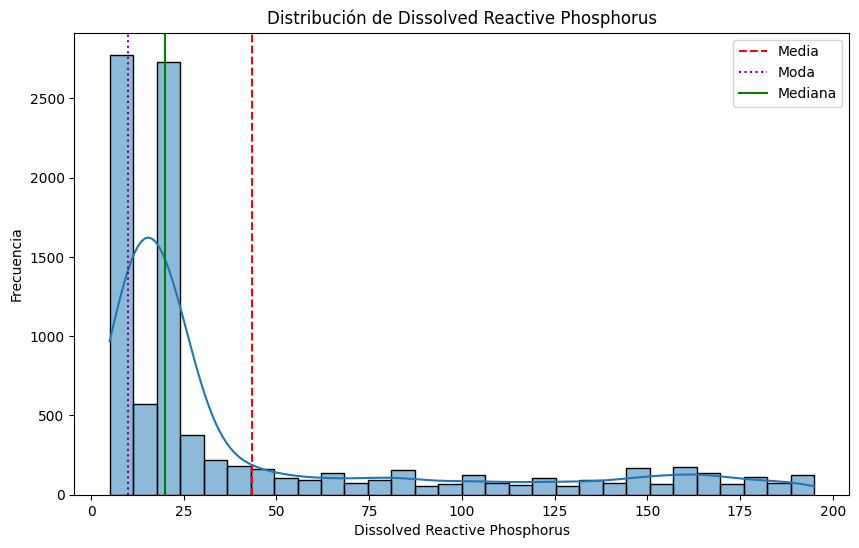

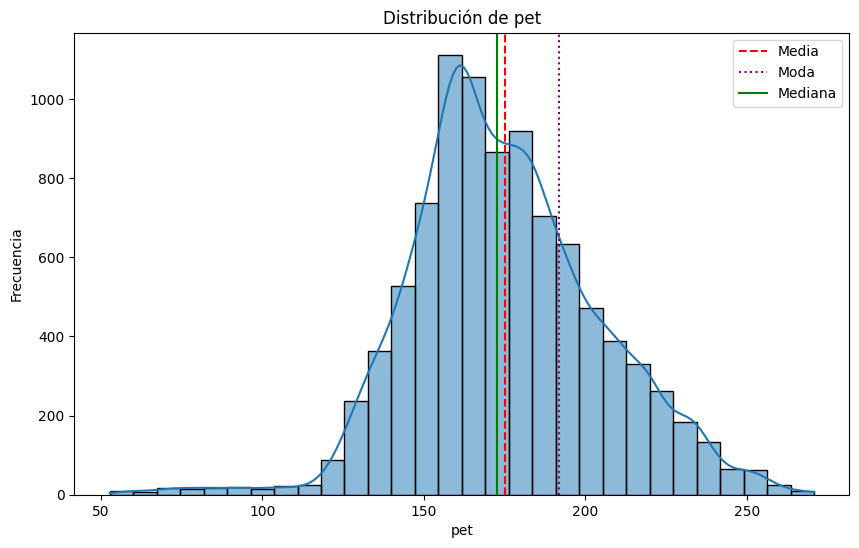

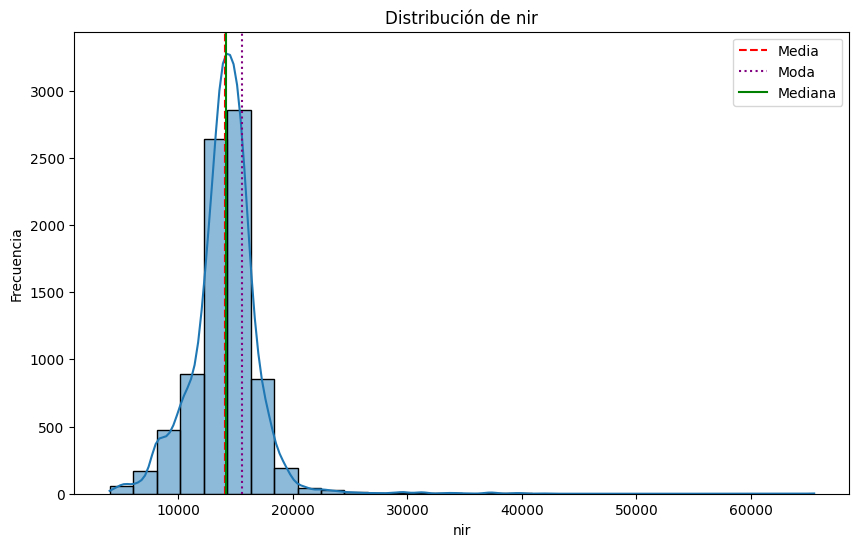

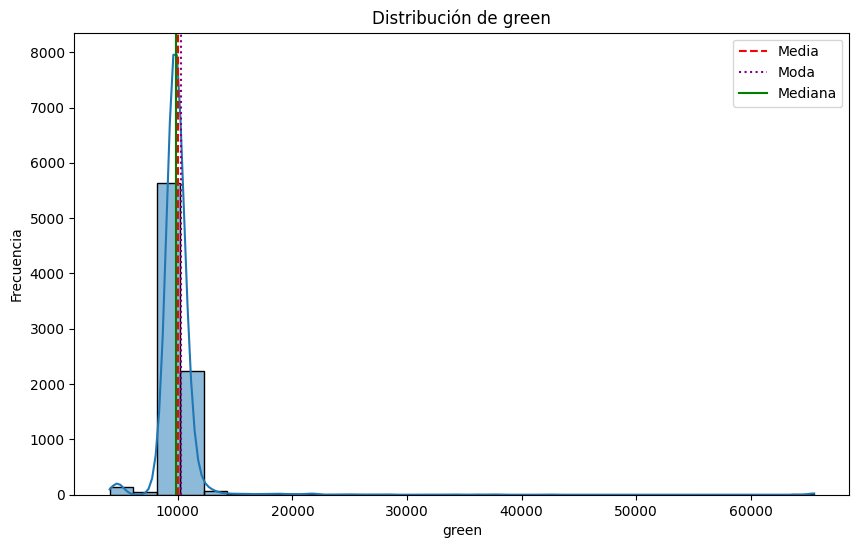

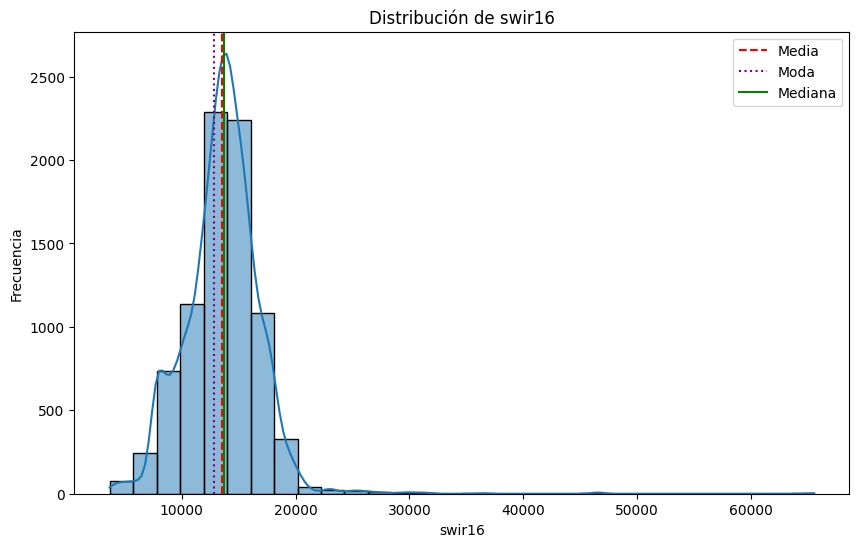

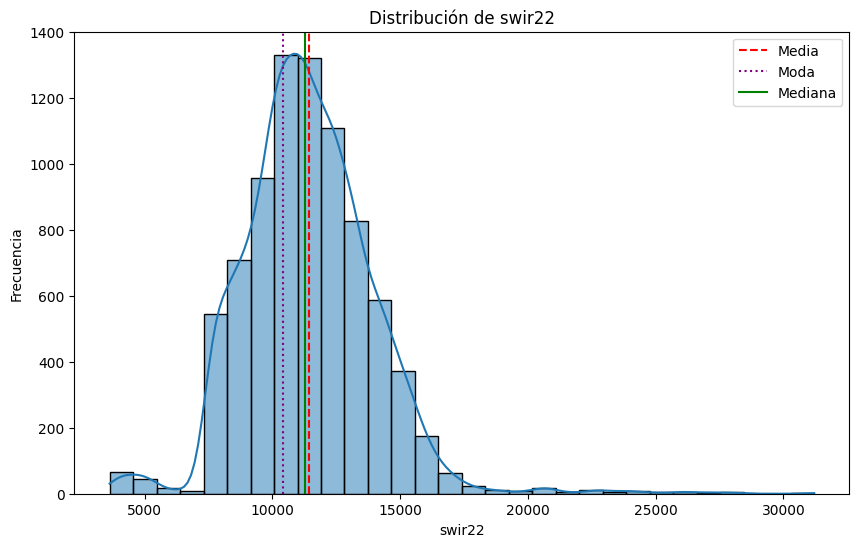

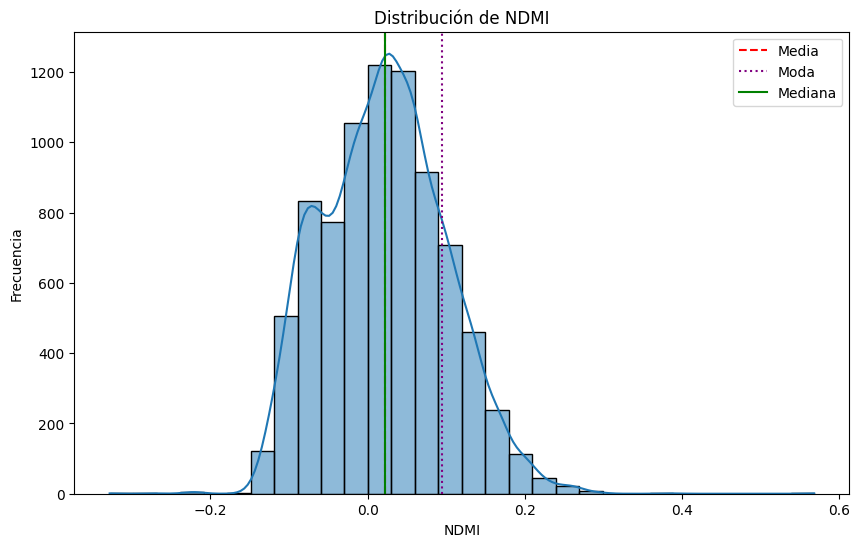

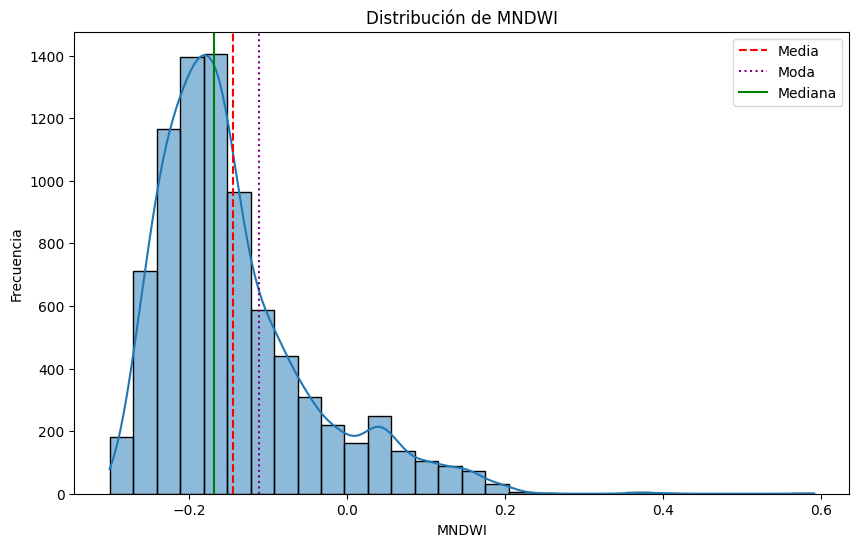

In [17]:
# +++++++++++++++++++++++++++++++++
# HISTOGRAMA CON MEDIA Y MEDIANA
# +++++++++++++++++++++++++++++++++

variables_numericas = df.select_dtypes(include=[np.number])

# Crear boxplots individuales
for columna in variables_numericas.columns:
    # Crear figura
    plt.figure(figsize=(10,6))
    
    # Histograma
    sns.histplot(df[columna], bins=30, kde=True)
    
    # Media
    plt.axvline(
        df[columna].mean(),
        color='red',
        linestyle='--',
        label='Media'
    )
    
    # Moda
    plt.axvline(
        df[columna].mode()[0],  
        color='purple',
        linestyle=':',
        label='Moda'
    )
    
    # Mediana
    plt.axvline(
        df[columna].median(),
        color='green',
        linestyle='-',
        label='Mediana'
    )
    
    # Títulos
    plt.title(f'Distribución de {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    
    # Leyenda
    plt.legend()
    
    # Mostrar
    plt.show()

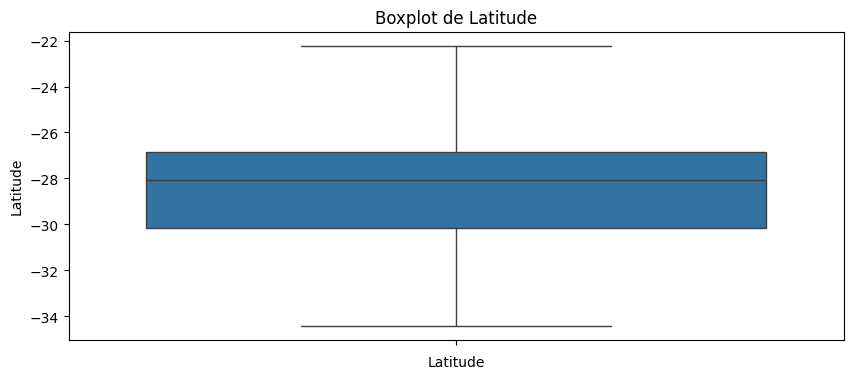

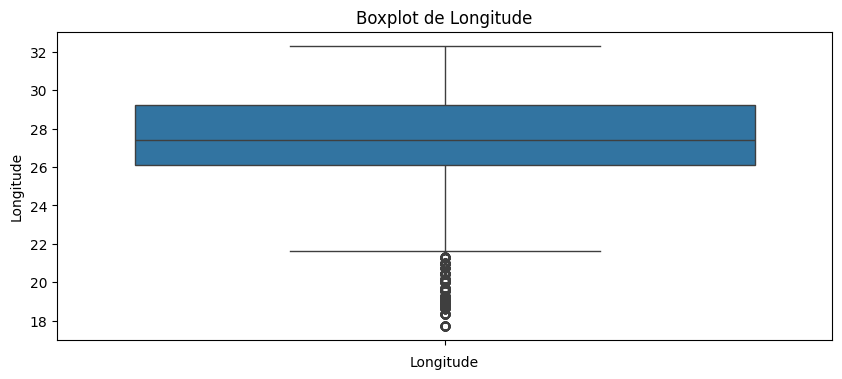

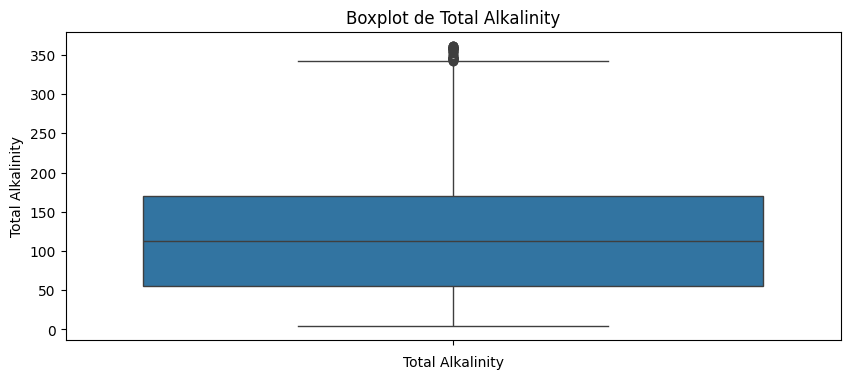

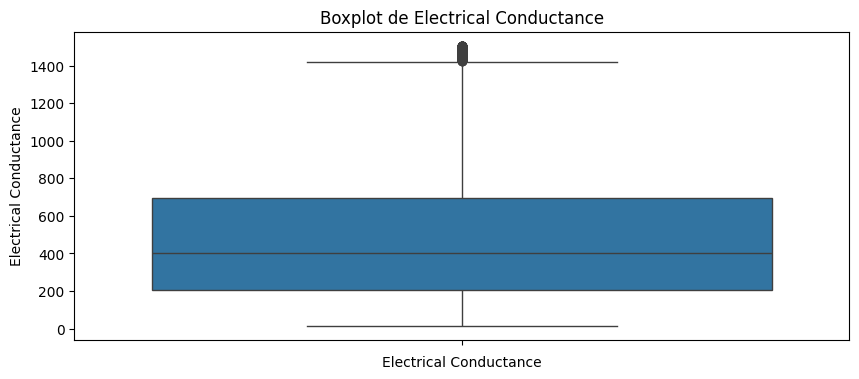

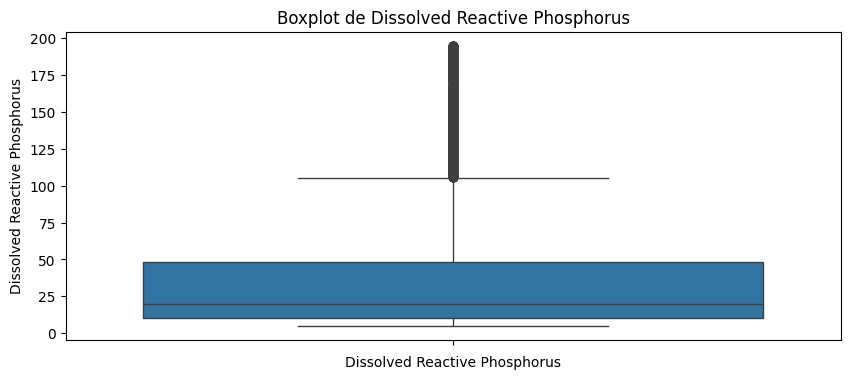

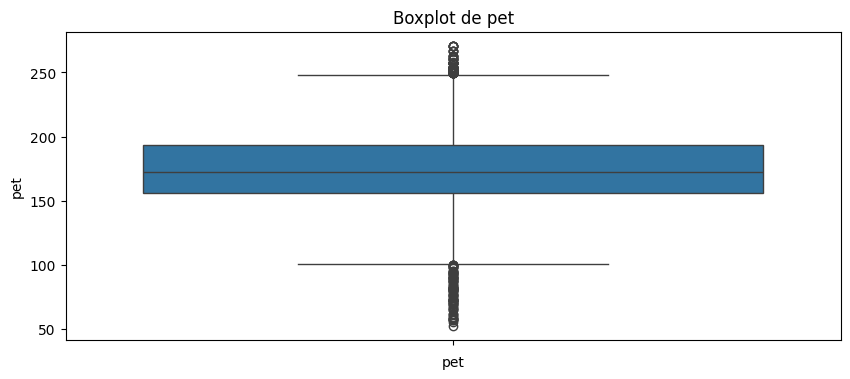

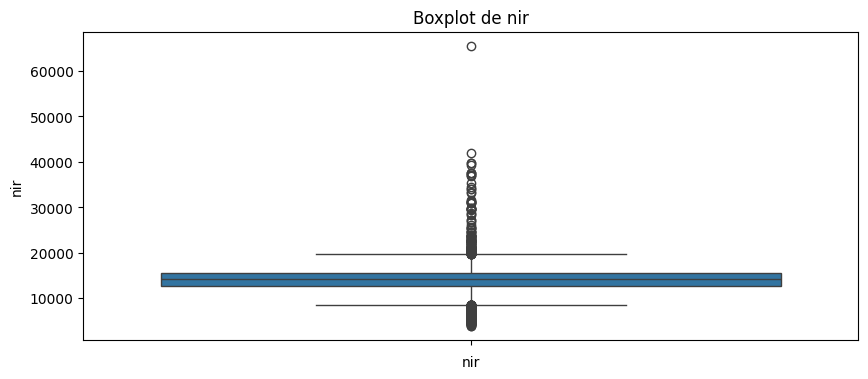

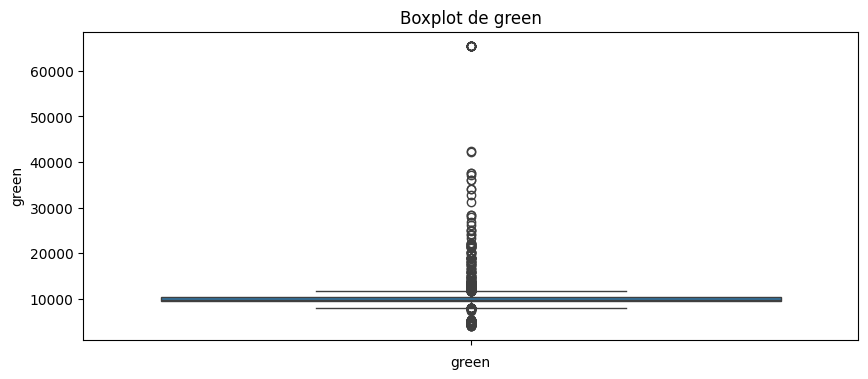

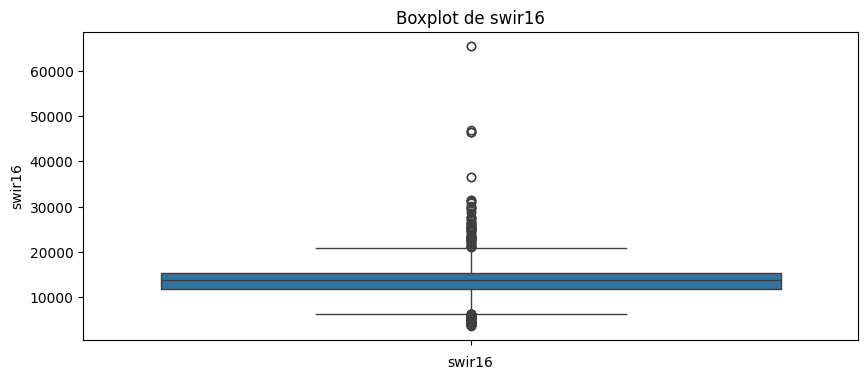

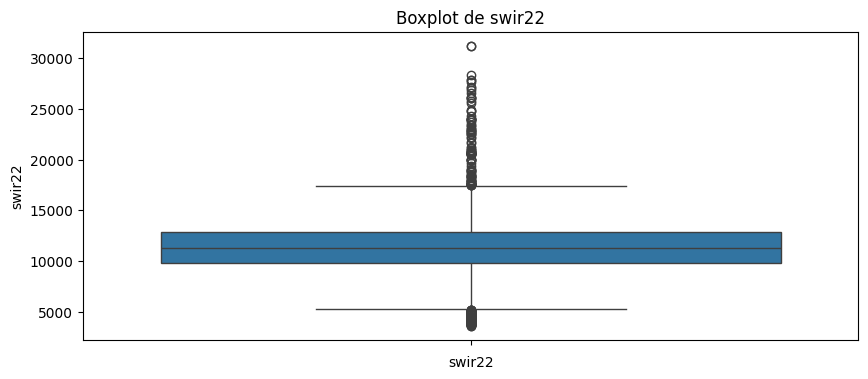

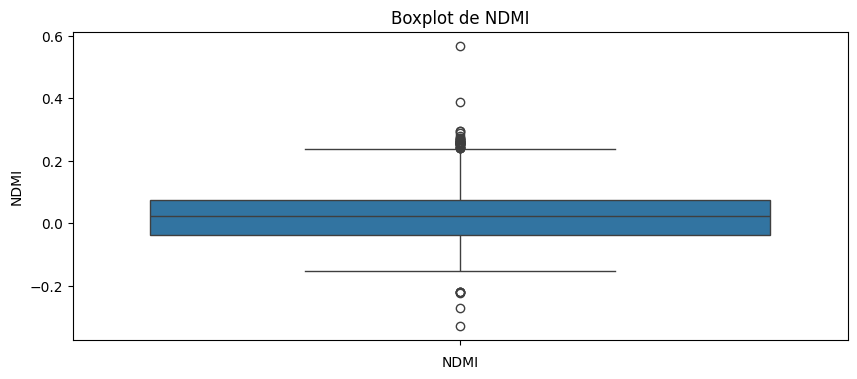

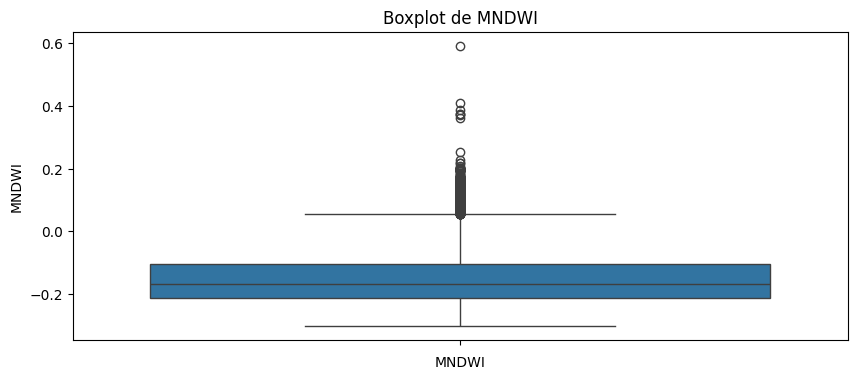

In [18]:
# +++++++++++++++++++++++++++++++++
# BOXPLOTS 
# +++++++++++++++++++++++++++++++++

# Variables numéricas
variables_numericas = df.select_dtypes(include=[np.number])

# Crear boxplots individuales
for columna in variables_numericas.columns:

    plt.figure(figsize=(10,4))

    sns.boxplot(y=df[columna])

    plt.title(f'Boxplot de {columna}')

    plt.xlabel(columna)

    plt.show()

In [19]:
# +++++++++++++++++++++++++++++++++
# MATRIZ DE CORRELACIÓN
# +++++++++++++++++++++++++++++++++

# Seleccionar variables numéricas
variables_numericas = df.select_dtypes(include=[np.number])

# Calcular correlación
correlacion = variables_numericas.corr()

# Mostrar matriz
print(correlacion)

                               Latitude  Longitude  Total Alkalinity  \
Latitude                       1.000000   0.624468          0.318495   
Longitude                      0.624468   1.000000          0.036686   
Total Alkalinity               0.318495   0.036686          1.000000   
Electrical Conductance         0.115727  -0.213808          0.692436   
Dissolved Reactive Phosphorus  0.257010   0.022743          0.316777   
pet                           -0.107426  -0.604577          0.263515   
nir                           -0.042791   0.050125          0.015579   
green                          0.010520  -0.012702          0.061622   
swir16                         0.121183   0.076827          0.191913   
swir22                         0.137749   0.060012          0.211446   
NDMI                          -0.233496  -0.057101         -0.274070   
MNDWI                         -0.116846  -0.123490         -0.154614   

                               Electrical Conductance  \
Latitu

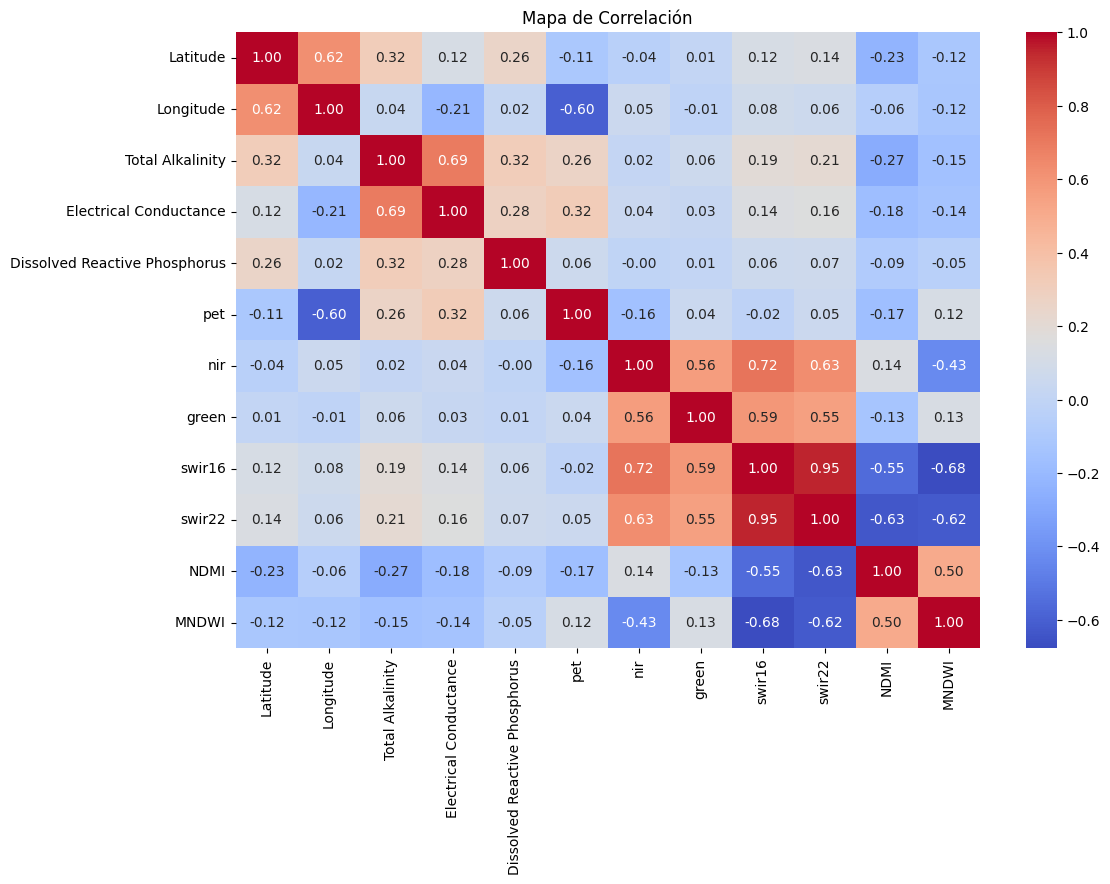

In [20]:
# +++++++++++++++++++++++++++++++++
# HEATMAP DE CORRELACIÓN
# +++++++++++++++++++++++++++++++++

plt.figure(figsize=(12,8))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Mapa de Correlación")

plt.show()

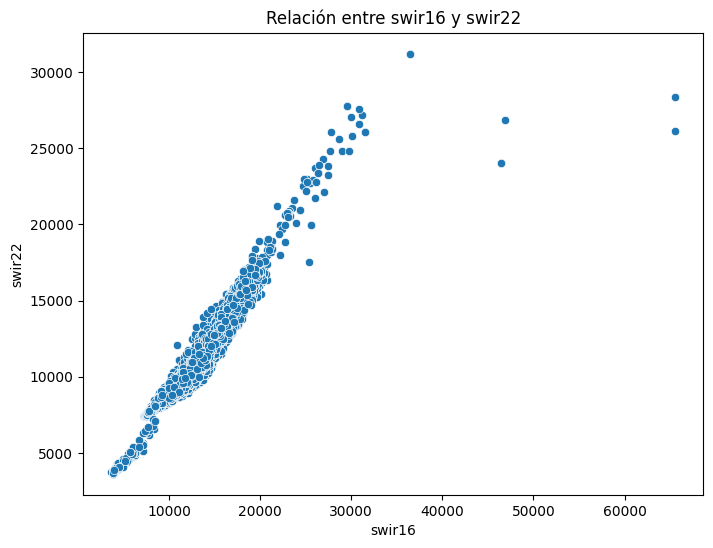

In [21]:
# +++++++++++++++++++++++++++++++++
# SCATTERPLOT - swir16 vs swir22
# +++++++++++++++++++++++++++++++++

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["swir16"],
    y=df["swir22"]
)

plt.title("Relación entre swir16 y swir22")

plt.xlabel("swir16")
plt.ylabel("swir22")

plt.show()

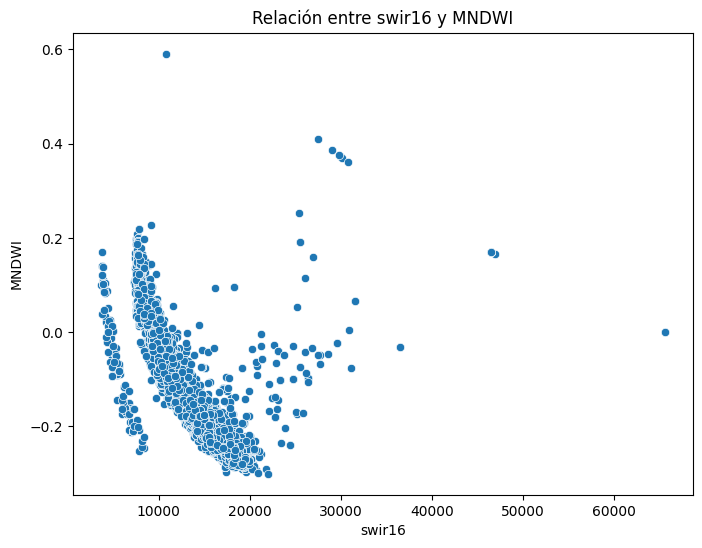

In [22]:
# +++++++++++++++++++++++++++++++++
# SCATTERPLOT - MNDWI vs swir16
# +++++++++++++++++++++++++++++++++

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["swir16"],
    y=df["MNDWI"]
)

plt.title("Relación entre swir16 y MNDWI")

plt.xlabel("swir16")
plt.ylabel("MNDWI")

plt.show()